In this notebook we test out Microstructure generator classes.

In [1]:
import torch
from microstructures import CentralFiber, CentralCornerFiber, RandomBlocks, Layered

In [2]:
resolution = 96
device = "cuda"
dtype = torch.float64 

# Volumetric fractions to test
fhard_values = [0.25, 0.40, 0.50]

In [3]:
gen_central = CentralFiber(resolution=resolution)
gen_periodic = CentralCornerFiber(resolution=resolution)
gen_blocks = RandomBlocks(resolution=resolution, n_blocks=8)   # 8x8 como en RVE_geo.py
gen_layered = Layered(resolution=resolution, angle=45.0)        # Horizontal layers

print("✅ Generators instantiated successfully")
print(f"   Resolution = {resolution}")
print(f"   Device     = {device} | dtype = {dtype}")

✅ Generators instantiated successfully
   Resolution = 96
   Device     = cuda | dtype = torch.float64



STARTING VISUAL AND VOLUME FRACTION VERIFICATION

🔹 Testing fhard = 0.25
   CentralFiber       → real fhard = 0.24523 | shapes = torch.Size([1, 96, 96]), torch.Size([96, 96])


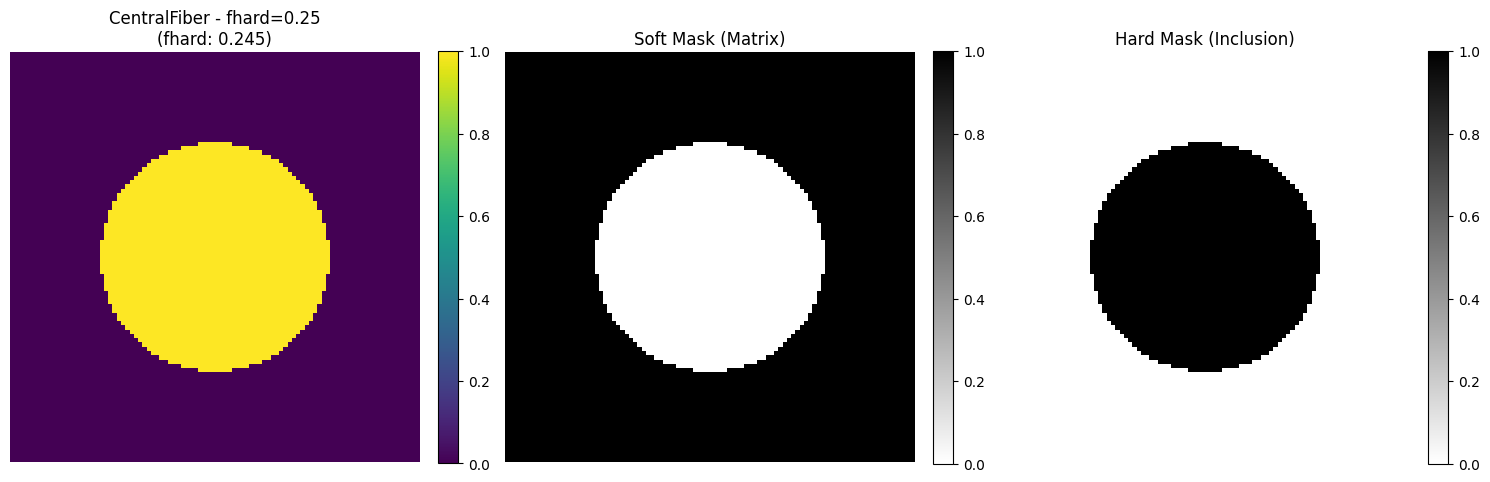

   CentralCornerFiber → real fhard = 0.25130 | shapes = torch.Size([1, 96, 96]), torch.Size([96, 96])


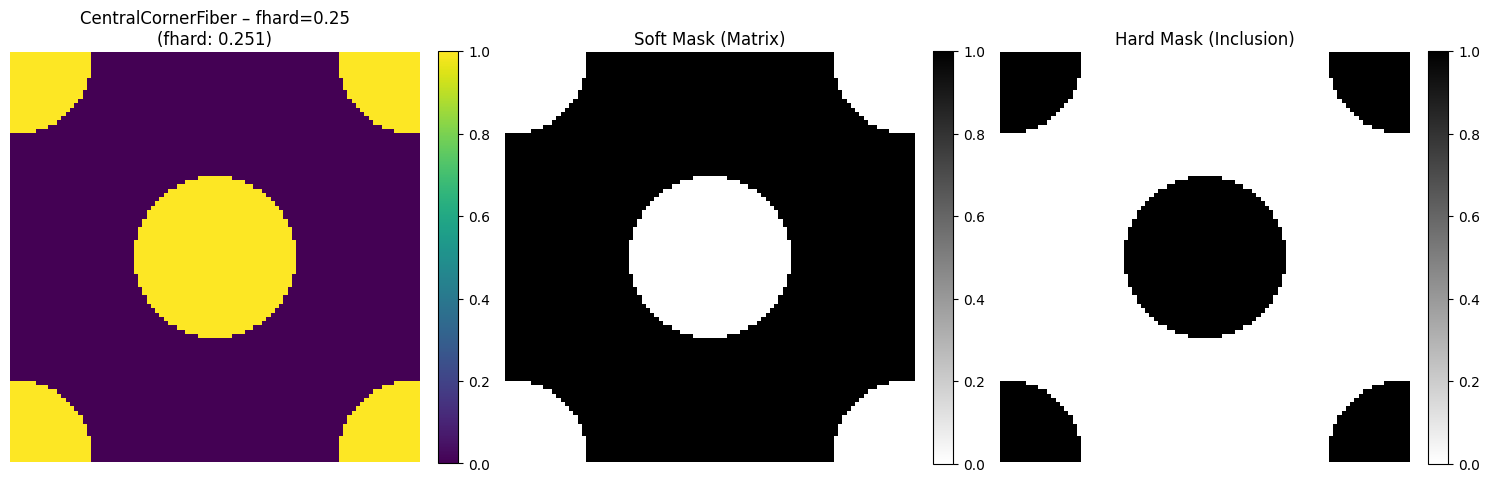

   RandomBlocks       → real fhard = 0.25000 | shapes = torch.Size([1, 96, 96]), torch.Size([96, 96])


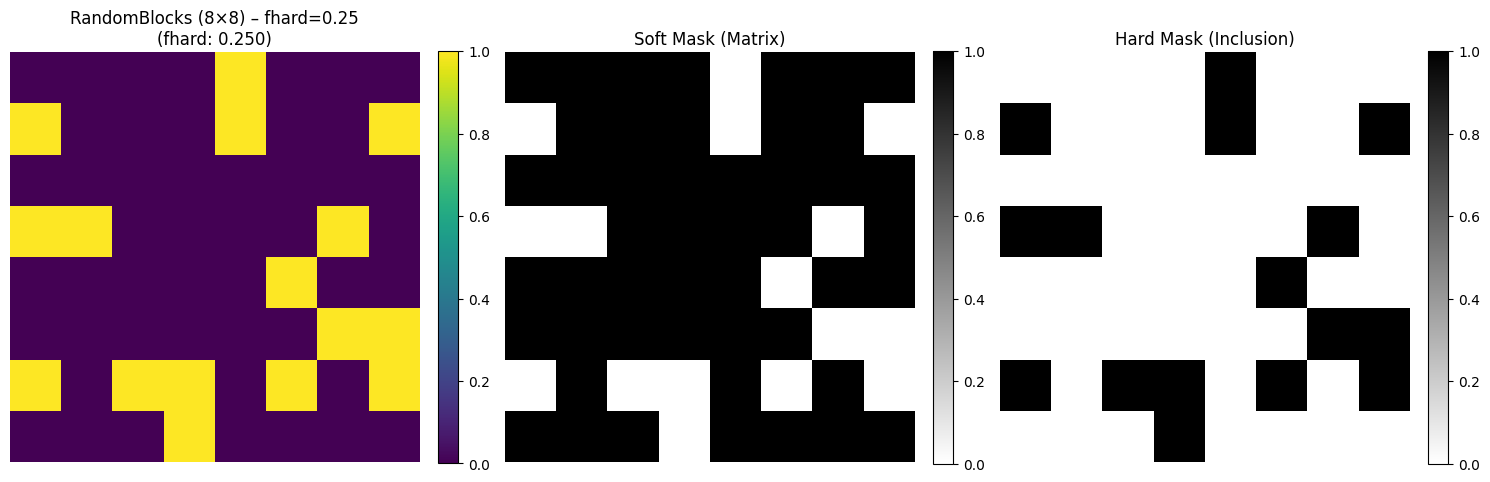

   Layered            → real fhard = 0.28743 | shapes = torch.Size([1, 96, 96]), torch.Size([96, 96])


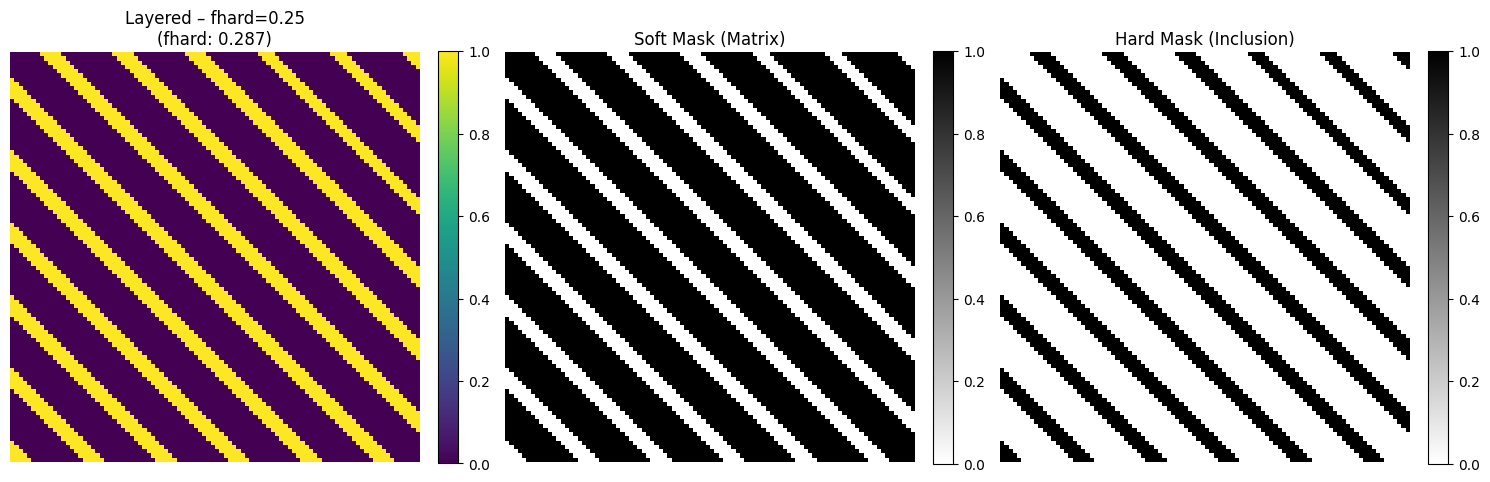


🔹 Testing fhard = 0.40
   CentralFiber       → real fhard = 0.39236 | shapes = torch.Size([1, 96, 96]), torch.Size([96, 96])


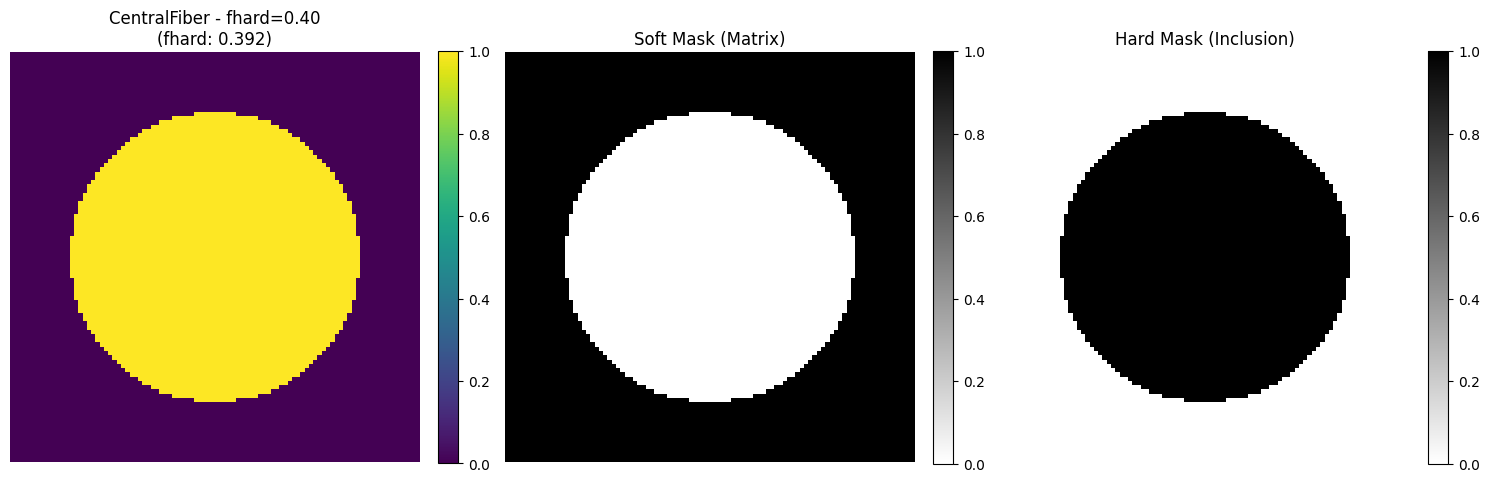

   CentralCornerFiber → real fhard = 0.40017 | shapes = torch.Size([1, 96, 96]), torch.Size([96, 96])


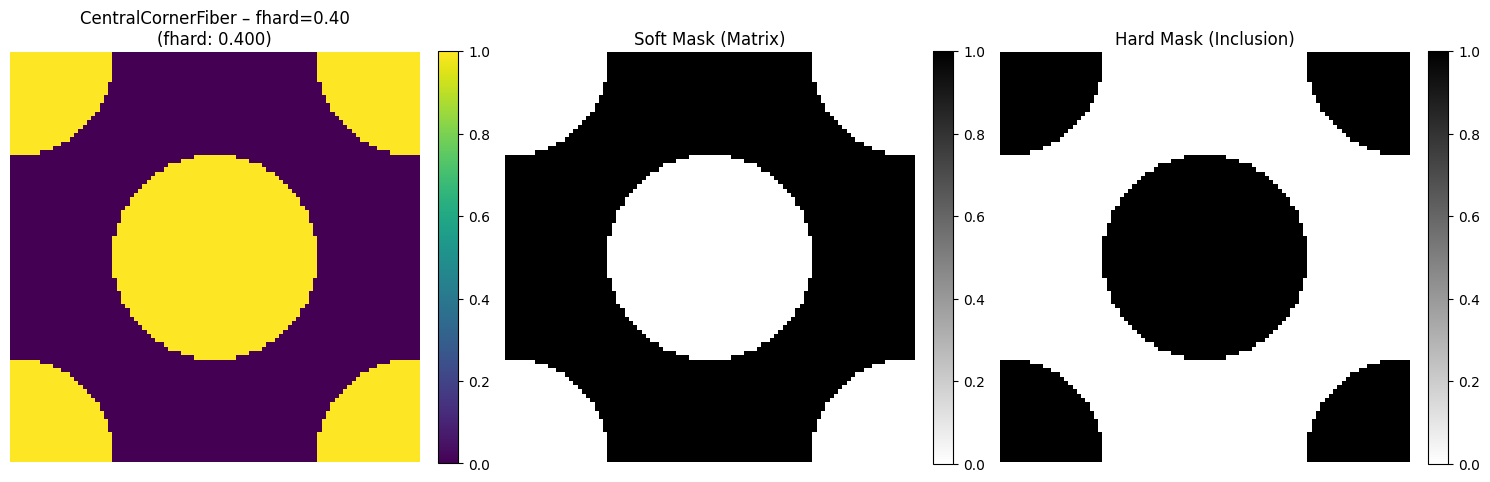

   RandomBlocks       → real fhard = 0.40625 | shapes = torch.Size([1, 96, 96]), torch.Size([96, 96])


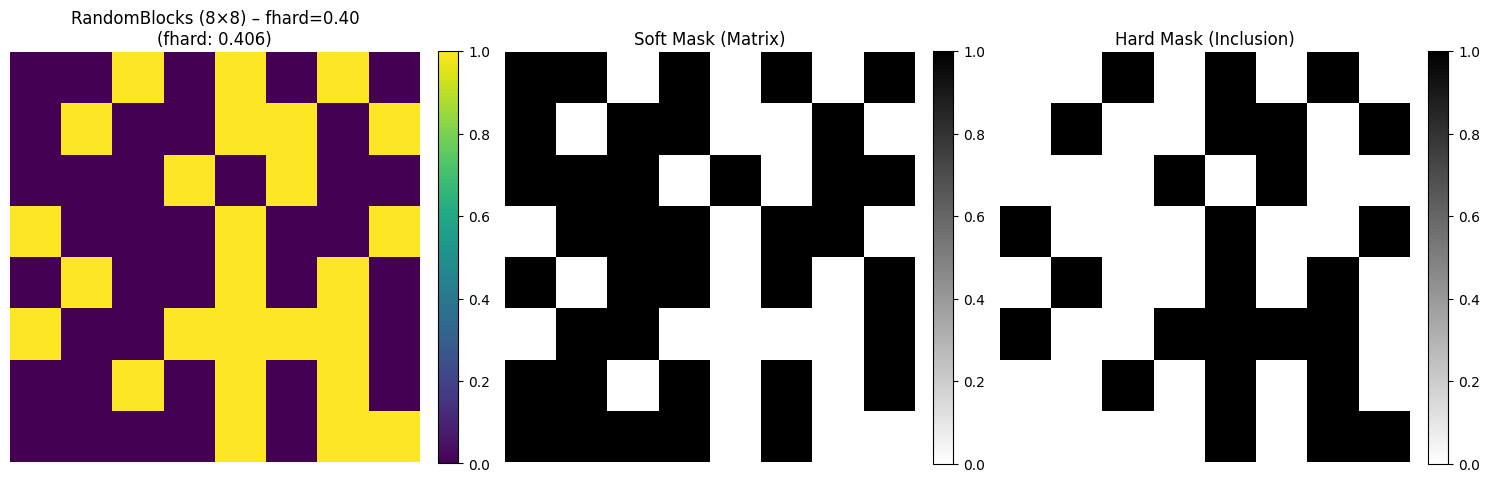

   Layered            → real fhard = 0.41048 | shapes = torch.Size([1, 96, 96]), torch.Size([96, 96])


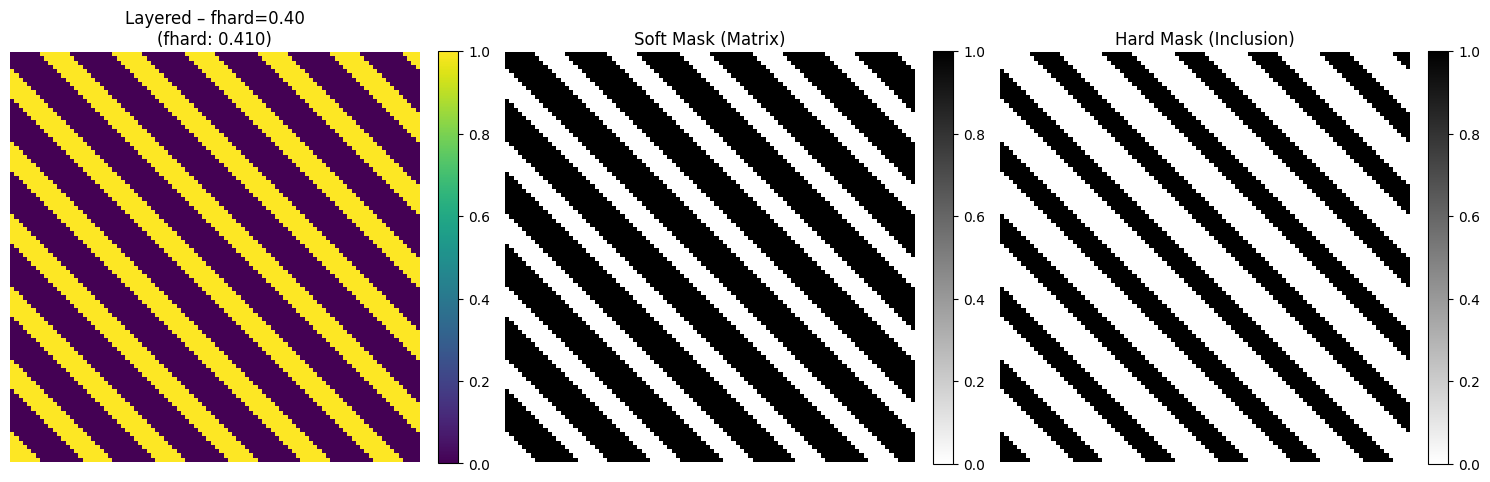


🔹 Testing fhard = 0.50
   CentralFiber       → real fhard = 0.48915 | shapes = torch.Size([1, 96, 96]), torch.Size([96, 96])


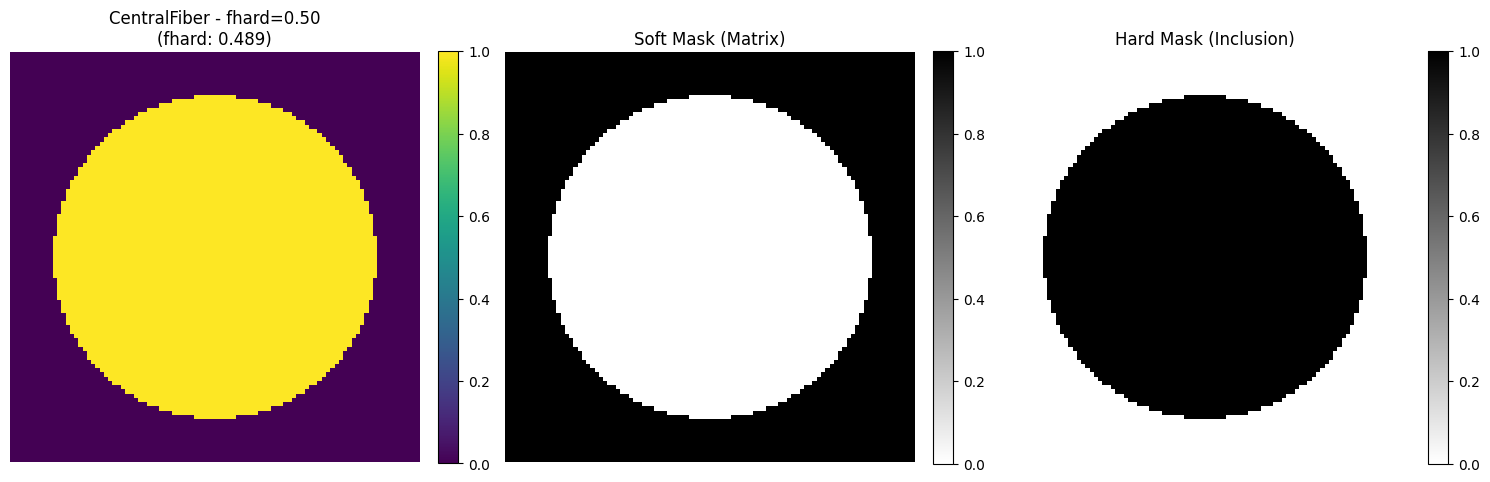

   CentralCornerFiber → real fhard = 0.50000 | shapes = torch.Size([1, 96, 96]), torch.Size([96, 96])


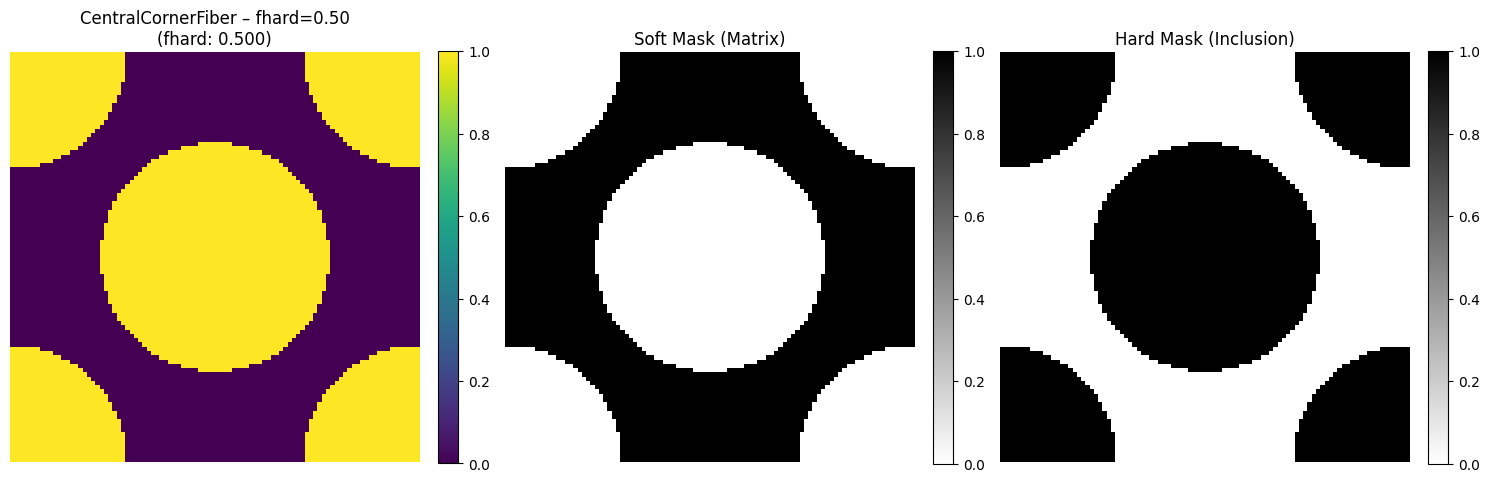

   RandomBlocks       → real fhard = 0.50000 | shapes = torch.Size([1, 96, 96]), torch.Size([96, 96])


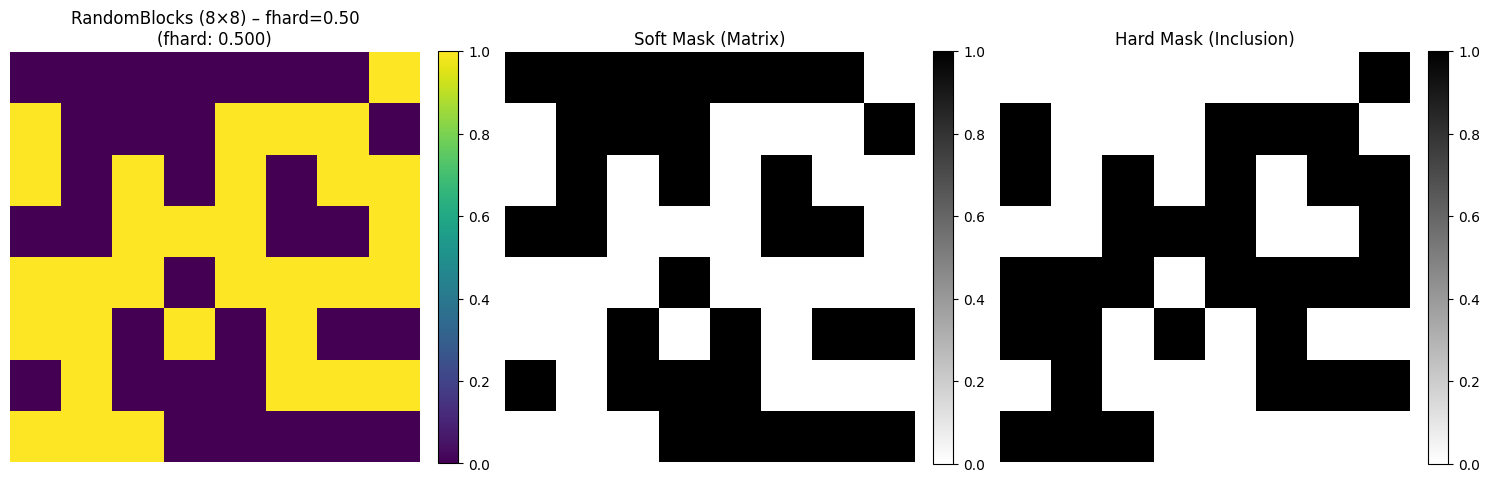

   Layered            → real fhard = 0.52843 | shapes = torch.Size([1, 96, 96]), torch.Size([96, 96])


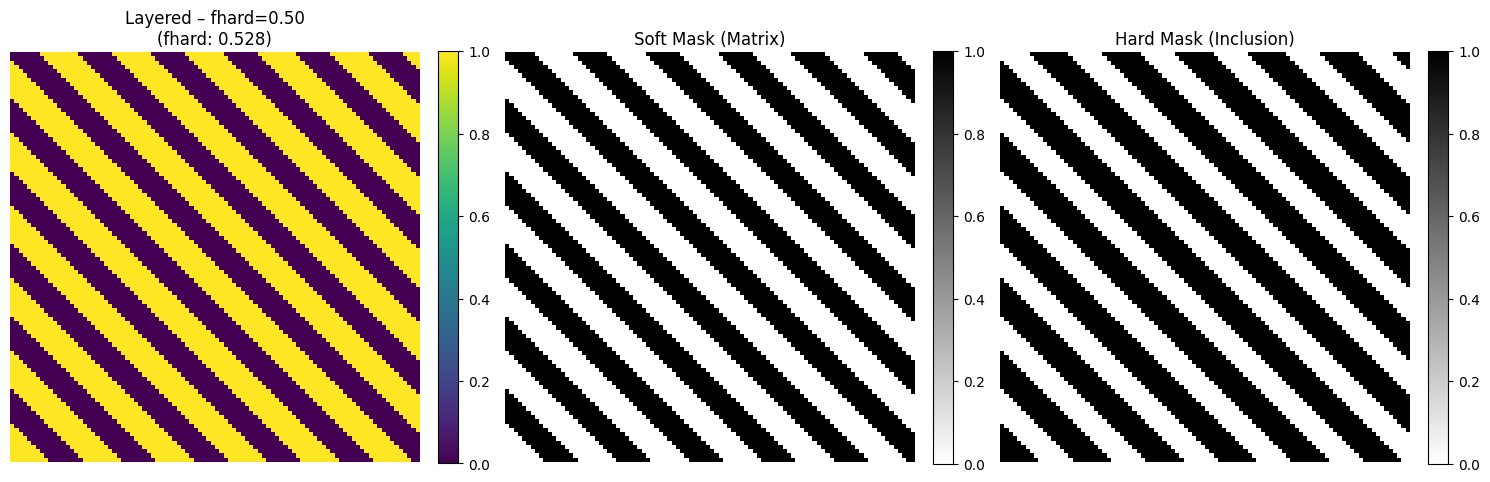


✅ Verification completed!
   • All shapes are consistent: phase=(1,96,96) | masks=(96,96)
   • Volume fraction (fhard) is respected with analytical/exact precision


In [4]:
print("\n" + "="*80)
print("STARTING VISUAL AND VOLUME FRACTION VERIFICATION")
print("="*80)

for fhard in fhard_values:
    print(f"\n🔹 Testing fhard = {fhard:.2f}")
    
    # CentralFiber
    gen_central.generate(fhard, device=device, dtype=dtype)
    print(f"   CentralFiber       → real fhard = {gen_central.phase_tensor.mean().item():.5f} | shapes = {gen_central.phase_tensor.shape}, {gen_central.mask_hard.shape}")
    gen_central.plot(title=f"CentralFiber - fhard={fhard:.2f}")
    
    # CentralCornerFiber
    gen_periodic.generate(fhard, device=device, dtype=dtype)
    print(f"   CentralCornerFiber → real fhard = {gen_periodic.phase_tensor.mean().item():.5f} | shapes = {gen_periodic.phase_tensor.shape}, {gen_periodic.mask_hard.shape}")
    gen_periodic.plot(title=f"CentralCornerFiber – fhard={fhard:.2f}")
    
    # RandomBlocks
    gen_blocks.generate(fhard, device=device, dtype=dtype)
    print(f"   RandomBlocks       → real fhard = {gen_blocks.phase_tensor.mean().item():.5f} | shapes = {gen_blocks.phase_tensor.shape}, {gen_blocks.mask_hard.shape}")
    gen_blocks.plot(title=f"RandomBlocks (8×8) – fhard={fhard:.2f}")
    
    # Layered
    gen_layered.generate(fhard, device=device, dtype=dtype)
    print(f"   Layered            → real fhard = {gen_layered.phase_tensor.mean().item():.5f} | shapes = {gen_layered.phase_tensor.shape}, {gen_layered.mask_hard.shape}")
    gen_layered.plot(title=f"Layered – fhard={fhard:.2f}")

print("\n✅ Verification completed!")
print("   • All shapes are consistent: phase=(1,96,96) | masks=(96,96)")
print("   • Volume fraction (fhard) is respected with analytical/exact precision")

Here we test "to_mesh" method.

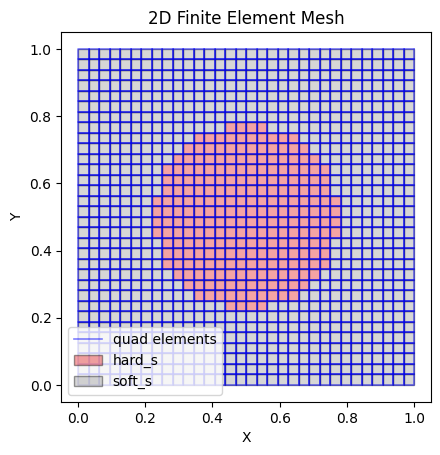

In [5]:
gen = CentralFiber(resolution=64)
gen.generate(fhard=0.25, device=device, dtype=dtype)
mesh, pairs_lr, pairs_bt = gen.to_mesh(lx=1.0, ly=1.0)

mesh.plot(element_groups_to_plot=['hard_s', 'soft_s'], show_nodes=False)